# Read output files from Delft3D and compare with measurements

NETCDF format output

Author: Sofia Midauar

Date: March 2025

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import glob2 as glob
from scipy.interpolate import interp1d
import platform
import os
import sys
import seaborn as sns
import re
from matplotlib import dates as mpl_dates
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.dates as mdates
import calendar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime, timedelta
from datetime import date, timedelta

In [2]:
%config Completer.use_jedi = False

In [3]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
figs_path = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_factor065_realisticcoverage/'

# Reading model output files - .netcdf

In [5]:
fpv_run = glob.glob('//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_real_nogaps/trim*.nc')
fpv_run

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_real_nogaps\\trim-FPV_real_nogaps.nc']

In [6]:
no_fpv_run = glob.glob('//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/validation/trim*.nc')
no_fpv_run

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/validation\\trim-validation_fulldata_spatialmeteo.nc']

In [7]:
# Creates list with depth of measurements
depth_obs = [0.5, 1, 2, 3, 4, 5, 6, 7]
depth_obs_str = []

for i in depth_obs:
    name = (str(i) + 'm')
    depth_obs_str.append(name)
    
depth_obs_str

['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m']

# Water depth

## Read and transform data

In [8]:
# Opens delft output and extracts variables of interest - no FPV
temp_nofpv = xr.open_dataset(no_fpv_run[0])
depth_noFPV = temp_nofpv[["ZK", "S1"]].isel(M = 20, N = 32, K_INTF = 0)
depth_noFPV["depth_m_noFPV"] = depth_noFPV.S1 - depth_noFPV.ZK
depth_noFPV = depth_noFPV.to_dataframe()
depth_noFPV.drop(depth_noFPV.columns[[0,1,2,3]], axis = 1, inplace = True)

# Opens delft output and extracts variables of interest - FPV
temp_fpv = xr.open_dataset(fpv_run[0])
depth_FPV = temp_fpv[["ZK", "S1"]].isel(M = 20, N = 32, K_INTF = 0)
depth_FPV["depth_m_FPV"] = depth_FPV.S1 - depth_FPV.ZK
depth_FPV = depth_FPV.to_dataframe()
depth_FPV.drop(depth_FPV.columns[[0,1,2,3]], axis = 1, inplace = True)

# create new dataframe
depth_compare = depth_noFPV.merge(depth_FPV, on = 'time', how = 'inner')
depth_compare.head(2)

,depth_m_noFPV,depth_m_FPV
time,,
2022-09-09 00:00:00,8.50000,8.500000
2022-09-09 06:00:00,8.49902,8.499052


In [9]:
# Melt data for boxplot - under FPV location
depth_boxplot = pd.melt(depth_compare[[depth_compare.columns[0],
                                       depth_compare.columns[1]]])
depth_boxplot.head(2)

,variable,value
0,depth_m_noFPV,8.50000
1,depth_m_noFPV,8.49902


## Numerical comparison depth

In [10]:
## Numerical comparison
# Number of rows (n)
n = len(depth_compare)

depth_compare['abs_dev'] = abs(depth_compare[depth_compare.columns[1]] - 
                               depth_compare[depth_compare.columns[0]]) # FPV - noFPV 
depth_compare['sq_dev'] = (depth_compare[depth_compare.columns[1]] - 
                           depth_compare[depth_compare.columns[0]]) ** 2

# calculates the mean absolute deviation and the root mean squared deviation
MAD_depth = (1/n) * depth_compare['abs_dev'].sum()
RMSD_depth = ((1/n) * (depth_compare['sq_dev'].sum()) ) ** 0.5

print('MAD depth = %0.4f' %MAD_depth)
print('RMSD depth = %0.4f' %RMSD_depth)

MAD depth = 0.1705
RMSD depth = 0.2086


## Plots

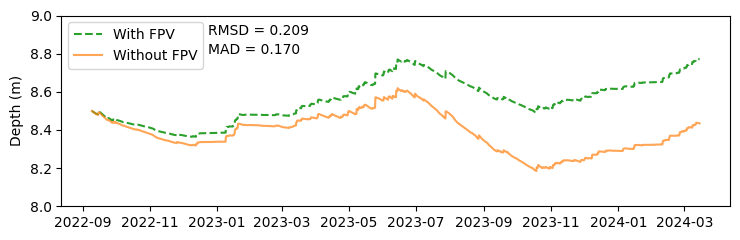

In [128]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [7.5,2.5], sharex = False, sharey = False)
pal = sns.color_palette("tab10", 6) # set color range

ax.plot(depth_compare.index, depth_compare['depth_m_FPV'], linewidth='1.5', label = 'With FPV', 
        linestyle = '--', color = pal.as_hex()[2])
ax.plot(depth_compare.index, depth_compare['depth_m_noFPV'], linewidth='1.5', label = 'Without FPV', 
        linestyle = '-', alpha = 0.7, color = pal.as_hex()[1])

ax.yaxis.set_label_text('Depth (m)', size = 10)

ax.text(19350, 8.9, 'RMSD = %0.3f' % RMSD_depth, color = 'k', fontsize = 10)
ax.text(19350, 8.8, 'MAD = %0.3f' % MAD_depth, color = 'k', fontsize = 10)

ax.legend(loc = "upper left")
ax.set_ylim(8,9)

plt.tight_layout()

# Save graph
plt.savefig(figs_path + 'depth_with_withoutFPV_timeseries.jpeg', dpi=300)

plt.show();

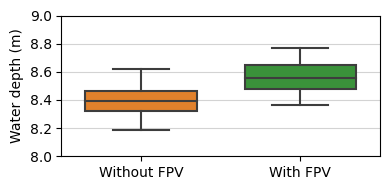

In [127]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [4,2])
pal = sns.color_palette("tab10",4)

sns.boxplot(x = "variable", y = "value", data = depth_boxplot,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax)

ax.set_xticks([0,1], ['Without FPV', 'With FPV'],
              fontsize = 10)

ax.set_ylim(8,9)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Water depth (m)', fontsize = 10)
ax.xaxis.set_label_text('')

# ax.hlines(y = 0, xmin = 0, xmax = 9, color = 'r')
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.tight_layout() # Para ajustar melhor os gráficos
plt.savefig(figs_path + 'depth_with_withoutFPV_boxplot.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

# Water temperature

## Read and transform data

No FPV run

In [10]:
# Opens delft output and extracts variables of interest
output_nofpv = xr.open_dataset(no_fpv_run[0])
output_temp_underFPV = output_nofpv[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)
output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR
data_noFPV = np.empty((len(output_temp_underFPV.time.values), 8))

# calculates temperature per depth (matching measurements) for each timestep
for i in range(len(output_temp_underFPV.time.values)):
    output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
    depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
    temp = output_temp_underFPV_t.R1.values # gets water temperature value
    time = output_temp_underFPV_t.time.values # gets timestep analysed
    temp = temp[depth > 0] # gets temperature values for depth > 0
    depth = depth[depth > 0] # gets depth values > 0
    f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
    data_noFPV[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep

# Creates new dataframe with information on time and depth of the modelled temperature
WT_underFPV_noFPV = pd.DataFrame(data_noFPV)
times_t = pd.DataFrame(output_temp_underFPV.time.values)
WT_underFPV_noFPV['time'] = times_t
WT_underFPV_noFPV.set_index('time', inplace = True)
WT_underFPV_noFPV.columns = depth_obs_str
WT_underFPV_noFPV.head(2)

,0.5m,1m,2m,3m,4m,5m,6m,7m
time,,,,,,,,
2022-09-09 00:00:00,25.645449,25.591359,25.478496,25.359496,25.392140,25.175947,24.767722,24.473604
2022-09-09 06:00:00,25.185508,25.192014,25.202716,25.209000,25.212645,25.213270,24.799250,24.487643


In [11]:
# prepare df for comparison
for timestep in range(len(WT_underFPV_noFPV.index.values)):
    temp = WT_underFPV_noFPV[WT_underFPV_noFPV.index == WT_underFPV_noFPV.index[timestep]]
    temp.index.names = ['']
    temp_2 = temp.T
    temp_2['time'] = temp.index[0]
    temp_2.reset_index(inplace = True)
    temp_2.rename(columns = {temp_2.columns[0]:'depth_m',
                             temp_2.columns[1]:'WT_noFPV_underFPV'}, inplace = True)
    if timestep == 0:
        WT_underFPV_noFPV_df = temp_2.copy()
    else:
        WT_underFPV_noFPV_df = pd.concat([WT_underFPV_noFPV_df, temp_2])

WT_underFPV_noFPV_df.head(2)

,depth_m,WT_noFPV_underFPV,time
0,0.5m,25.645449,2022-09-09
1,1m,25.591359,2022-09-09


FPV run

In [12]:
# Opens delft output and extracts variables of interest
output_fpv = xr.open_dataset(fpv_run[0])
output_temp_underFPV = output_fpv[["R1", "ZK_LYR", "S1"]].isel(LSTSCI = 0, M = 20, N = 32)
output_temp_underFPV["DK_LYR"] = output_temp_underFPV.S1 - output_temp_underFPV.ZK_LYR
data_FPV = np.empty((len(output_temp_underFPV.time.values), 8))

# calculates temperature per depth (matching measurements) for each timestep
for i in range(len(output_temp_underFPV.time.values)):
    output_temp_underFPV_t = output_temp_underFPV.isel(time = i) # subsets for timestep analysed
    depth = output_temp_underFPV_t.DK_LYR.values # gets depth values of modelled temperature
    temp = output_temp_underFPV_t.R1.values # gets water temperature value
    time = output_temp_underFPV_t.time.values # gets timestep analysed
    temp = temp[depth > 0] # gets temperature values for depth > 0
    depth = depth[depth > 0] # gets depth values > 0
    f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
    data_FPV[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep

# Creates new dataframe with information on time and depth of the modelled temperature
WT_underFPV_FPV = pd.DataFrame(data_FPV)
times_t = pd.DataFrame(output_temp_underFPV.time.values)
WT_underFPV_FPV['time'] = times_t
WT_underFPV_FPV.set_index('time', inplace = True)
WT_underFPV_FPV.columns = depth_obs_str
WT_underFPV_FPV.head(2)

,0.5m,1m,2m,3m,4m,5m,6m,7m
time,,,,,,,,
2022-09-09 00:00:00,25.645449,25.591359,25.478496,25.359496,25.392140,25.175947,24.767722,24.473604
2022-09-09 06:00:00,25.190582,25.196921,25.207332,25.213371,25.216639,25.214617,24.799598,24.487076


In [13]:
# prepare df for comparison
for timestep in range(len(WT_underFPV_FPV.index.values)):
    temp = WT_underFPV_FPV[WT_underFPV_FPV.index == WT_underFPV_FPV.index[timestep]]
    temp.index.names = ['']
    temp_2 = temp.T
    temp_2['time'] = temp.index[0]
    temp_2.reset_index(inplace = True)
    temp_2.rename(columns = {temp_2.columns[0]:'depth_m',
                             temp_2.columns[1]:'WT_FPV_underFPV'}, inplace = True)
    if timestep == 0:
        WT_underFPV_FPV_df = temp_2.copy()
    else:
        WT_underFPV_FPV_df = pd.concat([WT_underFPV_FPV_df, temp_2])

WT_underFPV_FPV_df.head()

,depth_m,WT_FPV_underFPV,time
0,0.5m,25.645449,2022-09-09
1,1m,25.591359,2022-09-09
2,2m,25.478496,2022-09-09
3,3m,25.359496,2022-09-09
4,4m,25.392140,2022-09-09


Comparison df

In [14]:
# Join all data into one dataframe
WT_compare_underFPV = WT_underFPV_noFPV_df.copy()
WT_compare_underFPV = WT_compare_underFPV.merge(WT_underFPV_FPV_df, on = ['time', 'depth_m'], how = 'inner')
WT_compare_underFPV = WT_compare_underFPV[['time', 'depth_m', 'WT_FPV_underFPV', 'WT_noFPV_underFPV']]
WT_compare_underFPV.head(2)

,time,depth_m,WT_FPV_underFPV,WT_noFPV_underFPV
0,2022-09-09,0.5m,25.645449,25.645449
1,2022-09-09,1m,25.591359,25.591359


## Numerical comparison temperature

In [15]:
# Creates df with bias - one column per depth
layers = list(WT_compare_underFPV['depth_m'].unique())

temp_WT_bias_underFPV = WT_compare_underFPV.copy()
temp_WT_bias_underFPV['bias_underFPV'] = (WT_compare_underFPV['WT_FPV_underFPV'] - 
                                          WT_compare_underFPV['WT_noFPV_underFPV']) # with FPV - without FPV
temp_WT_bias_underFPV.set_index('time', inplace = True)

# Create df for first depth (0.5m)
WT_bias_underFPV = pd.DataFrame(temp_WT_bias_underFPV[temp_WT_bias_underFPV['depth_m'] == 
                                                      layers[0]][['bias_underFPV']])
WT_bias_underFPV.rename(columns = {'bias_underFPV':('bias_underFPV_' + str(layers[0]))}, inplace = True)

# Add columns for other depths
for depth in layers[1:]:
    temp = pd.DataFrame(temp_WT_bias_underFPV[temp_WT_bias_underFPV['depth_m'] == depth]['bias_underFPV'])
    temp.rename(columns = {'bias_underFPV':('bias_underFPV_' + str(depth))}, inplace = True)
    WT_bias_underFPV = WT_bias_underFPV.join(temp, on = 'time', how = 'inner')

WT_bias_underFPV.head(2)

,bias_underFPV_0.5m,bias_underFPV_1m,bias_underFPV_2m,bias_underFPV_3m,bias_underFPV_4m,bias_underFPV_5m,bias_underFPV_6m,bias_underFPV_7m
time,,,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.005075,0.004908,0.004616,0.004371,0.003994,0.001347,0.000348,-0.000568


In [16]:
# calculate summary numbers for results
results_WT = WT_bias_underFPV.copy()
results_WT['bias_depthav'] = results_WT.mean(axis = 1)
results_WT = results_WT[['bias_underFPV_0.5m', 'bias_underFPV_7m', 'bias_depthav']].copy()
results_WT.head(2)

,bias_underFPV_0.5m,bias_underFPV_7m,bias_depthav
time,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.005075,-0.000568,0.003011


In [17]:
# gets depth average for the whole simulation period
results_WT_2023 = results_WT.copy()
results_WT_2023 = results_WT_2023.loc['2023-01-01 00:00:00':'2023-12-31 00:00:00'] # april 1st to august 31st
depthav_2023 = results_WT_2023['bias_depthav'].mean()

results_WT_apr_aug = results_WT.loc['2023-04-01 00:00:00':'2023-08-31 00:00:00'] # april 1st to august 31st
depthav_apr_aug = results_WT_apr_aug['bias_depthav'].mean()

results_WT_oct22_jan23 = results_WT.loc['2022-10-01 00:00:00':'2023-01-31 00:00:00'] # Oct 2022 to Jan 2023
depthav_oct22_jan23 = results_WT_oct22_jan23['bias_depthav'].mean()

results_WT_oct23_jan24 = results_WT.loc['2023-10-01 00:00:00':'2024-01-31 00:00:00'] # Oct 2023 to Jan 2024
depthav_oct23_jan24 = results_WT_oct23_jan24['bias_depthav'].mean()

print('Depth averaged water temperature decrease due to FPVs coverage:')
print('')

print('2023:', f"{depthav_2023:.3f}")
print('April to August 2023:', f"{depthav_apr_aug:.3f}")
print('Oct 2022 to Jan 2023:', f"{depthav_oct22_jan23:.3f}")
print('Oct 2023 to jan 2024:', f"{depthav_oct23_jan24:.3f}")

Depth averaged water temperature decrease due to FPVs coverage:

2023: -1.506
April to August 2023: -2.196
Oct 2022 to Jan 2023: -0.960
Oct 2023 to jan 2024: -0.613


In [18]:
# gets layers' average for the whole simulation period
surface_WT_2023 = results_WT.copy()
surface_WT_2023 = surface_WT_2023.loc['2023-01-01 00:00:00':'2023-12-31 00:00:00'] # april 1st to august 31st
surface_2023 = surface_WT_2023['bias_underFPV_0.5m'].mean()

bottom_WT_2023 = results_WT.copy()
bottom_WT_2023 = bottom_WT_2023.loc['2023-01-01 00:00:00':'2023-12-31 00:00:00'] # april 1st to august 31st
bottom_2023 = bottom_WT_2023['bias_underFPV_7m'].mean()

surface_WT_Feb23 = results_WT.copy()
surface_WT_Feb23 = surface_WT_Feb23.loc['2023-02-01 00:00:00':'2023-02-28 00:00:00'] # april 1st to august 31st
surface_Feb23 = surface_WT_Feb23['bias_underFPV_0.5m'].mean()

bottom_WT_Feb23 = results_WT.copy()
bottom_WT_Feb23 = bottom_WT_Feb23.loc['2023-02-01 00:00:00':'2023-02-28 00:00:00'] # april 1st to august 31st
bottom_Feb23 = bottom_WT_Feb23['bias_underFPV_7m'].mean()

surface_WT_Jun23 = results_WT.copy()
surface_WT_Jun23 = surface_WT_Jun23.loc['2023-06-01 00:00:00':'2023-06-30 00:00:00'] # april 1st to august 31st
surface_Jun23 = surface_WT_Jun23['bias_underFPV_0.5m'].mean()

bottom_WT_Jun23 = results_WT.copy()
bottom_WT_Jun23 = bottom_WT_Jun23.loc['2023-06-01 00:00:00':'2023-06-30 00:00:00'] # april 1st to august 31st
bottom_Jun23 = bottom_WT_Jun23['bias_underFPV_7m'].mean()

print('Surface and bottom water temperature decrease due to FPVs coverage:')
print('')

print('Surface (0.5m) 2023:', f"{surface_2023:.3f}")
print('Bottom (7.0m) 2023:', f"{bottom_2023:.3f}")
print('Surface Feb 2023:', f"{surface_Feb23:.3f}")
print('Bottom Feb 2023:', f"{bottom_Feb23:.3f}")
print('Surface Jun 2023:', f"{surface_Jun23:.3f}")
print('Bottom Jun 2023:', f"{bottom_Jun23:.3f}")

Surface and bottom water temperature decrease due to FPVs coverage:

Surface (0.5m) 2023: -1.285
Bottom (7.0m) 2023: -1.893
Surface Feb 2023: -1.313
Bottom Feb 2023: -0.530
Surface Jun 2023: -1.393
Bottom Jun 2023: -3.099


In [17]:
# Calculates metrics for each depth
depths_fpv = list(WT_compare_underFPV['depth_m'].unique())
r2_list_underFPV = []
RMSD_list_underFPV = []
bias_list_underFPV = []

for depth in depths_fpv:
    temp = WT_compare_underFPV[WT_compare_underFPV['depth_m'] == depth]
    temp.set_index('time', inplace = True)
    n = len(temp)
    r2 = ((np.corrcoef(temp[temp.columns[1]], temp[temp.columns[2]])[0,1]) ** 2)
    temp.loc[:, 'sq_deviation'] = ((temp[temp.columns[2]] - temp[temp.columns[1]]) ** 2)
#     temp['sq_deviation'] = ((temp[temp.columns[2]] - temp[temp.columns[1]]) ** 2)
    RMSD = (((1/n) * (temp['sq_deviation'].sum()) ) ** 0.5)
    bias = (((temp[temp.columns[1]] - temp[temp.columns[2]]).sum()) / n) # with FPV - without FPV
    
    # Join results into lists
    r2_list_underFPV.append(r2)
    RMSD_list_underFPV.append(RMSD)
    bias_list_underFPV.append(bias)

print('r²:', r2_list_underFPV)
print('')
print('RMSE:', RMSD_list_underFPV)
print('')
print('Bias:', bias_list_underFPV)

r²: [0.9954210831912192, 0.9957517628430541, 0.9954178788815337, 0.9936418535161138, 0.989266252588261, 0.9841790455142359, 0.978766623098949, 0.975124492176062]

RMSE: [1.3527682261113332, 1.3049803586088073, 1.294165966614531, 1.3825741895942172, 1.547520369143007, 1.68686508480475, 1.8212883213645463, 1.912386547734149]

Bias: [-1.2376263308474846, -1.1960643536490854, -1.1790797978430427, -1.2375813707946348, -1.3381811449812633, -1.4174318085537743, -1.494355111882396, -1.5497281259258302]


<ipython-input-17-c8c5419e512b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp.loc[:, 'sq_deviation'] = ((temp[temp.columns[2]] - temp[temp.columns[1]]) ** 2)
<ipython-input-17-c8c5419e512b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp.loc[:, 'sq_deviation'] = ((temp[temp.columns[2]] - temp[temp.columns[1]]) ** 2)
<ipython-input-17-c8c5419e512b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [19]:
# Creates dfs with error according to depth
WT_metrics_underFPV = pd.DataFrame()
WT_metrics_underFPV['depths'] = depths_fpv[:]
WT_metrics_underFPV['r2_underFPV'] = r2_list_underFPV
WT_metrics_underFPV['RMSE_underFPV'] = RMSD_list_underFPV
WT_metrics_underFPV['Bias_underFPV'] = bias_list_underFPV

WT_metrics_underFPV.head(2)

NameError: name 'depths_fpv' is not defined

## Prep data for boxplot

In [20]:
temp_WT_bias_boxplot_underFPV = WT_bias_underFPV.copy()

# Creates columns with month
temp_WT_bias_boxplot_underFPV['month'] = temp_WT_bias_boxplot_underFPV.index.month
temp_WT_bias_boxplot_underFPV['year'] = temp_WT_bias_boxplot_underFPV.index.year
temp_WT_bias_boxplot_underFPV['year'] = temp_WT_bias_boxplot_underFPV['year'].apply(lambda x: str(x)[2:])
temp_WT_bias_boxplot_underFPV['month_str'] = ((temp_WT_bias_boxplot_underFPV['month'].apply(lambda x: 
                                                                                            calendar.month_abbr[x])) + 
                                              (temp_WT_bias_boxplot_underFPV['year']))

temp_WT_bias_boxplot_underFPV.head(2)

,bias_underFPV_0.5m,bias_underFPV_1m,bias_underFPV_2m,bias_underFPV_3m,bias_underFPV_4m,bias_underFPV_5m,bias_underFPV_6m,bias_underFPV_7m,month,year,month_str
time,,,,,,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9,22,Sep22
2022-09-09 06:00:00,0.005075,0.004908,0.004616,0.004371,0.003994,0.001347,0.000348,-0.000568,9,22,Sep22


In [21]:
# Adjusts format to one dataframe
for depth in range(0, len(temp_WT_bias_boxplot_underFPV.columns)-3,1):
    temp = pd.DataFrame(temp_WT_bias_boxplot_underFPV[temp_WT_bias_boxplot_underFPV.columns[[depth,-2,-1]]])
    temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
    temp['depth'] = (temp_WT_bias_boxplot_underFPV.columns[depth][14:-1])
    if depth == 0:
        WT_bias_boxplot_underFPV = temp
    else:
        WT_bias_boxplot_underFPV = pd.concat([WT_bias_boxplot_underFPV, temp])

WT_bias_boxplot_underFPV.dropna(inplace = True)
WT_bias_boxplot_underFPV.head(3)

,bias,year,month_str,depth
time,,,,
2022-09-09 00:00:00,0.000000,22,Sep22,0.5
2022-09-09 06:00:00,0.005075,22,Sep22,0.5
2022-09-09 12:00:00,-0.031281,22,Sep22,0.5


## Prep data for heatmaps

In [21]:
# Creates a df to plot heatmap - WATER TEMPERATURE
temp_WT_heatmap_underFPV = WT_compare_underFPV.dropna()
depths = list(temp_WT_heatmap_underFPV['depth_m'].unique())

for depth in range(0, len(depths),1):
    temp = pd.DataFrame(temp_WT_heatmap_underFPV[temp_WT_heatmap_underFPV['depth_m'] == depths[depth]])
    if depth == 0:
        WT_heatmap_underFPV = temp
    else:
        WT_heatmap_underFPV = pd.concat([WT_heatmap_underFPV, temp])

WT_heatmap_underFPV.dropna(inplace = True)

WT_heatmap_underFPV.head(2)

,time,depth_m,WT_FPV_underFPV,WT_noFPV_underFPV
0,2022-09-09 00:00:00,0.5m,25.645449,25.645449
8,2022-09-09 06:00:00,0.5m,25.190582,25.185508


In [22]:
# Creates a df to plot heatmap - WATER TEMPERATURE BIAS
temp_WT_bias_heatmap_underFPV = WT_bias_underFPV.copy()

for depth in range(0, len(temp_WT_bias_heatmap_underFPV.columns),1):
    temp = pd.DataFrame(temp_WT_bias_heatmap_underFPV[temp_WT_bias_heatmap_underFPV.columns[depth]])
    temp.rename(columns = {temp.columns[0]:'bias'}, inplace = True)
    temp['depth'] = float(temp_WT_bias_heatmap_underFPV.columns[depth][14:-1])
    if depth == 0:
        WT_bias_heatmap_underFPV = temp
    else:
        WT_bias_heatmap_underFPV = pd.concat([WT_bias_heatmap_underFPV, temp])

WT_bias_heatmap_underFPV.dropna(inplace = True)

WT_bias_heatmap_underFPV.head(2)

,bias,depth
time,,
2022-09-09 00:00:00,0.000000,0.5
2022-09-09 06:00:00,0.005075,0.5


## Pivot table

In [23]:
# Creates pivot table with data for heatmap - WT
WT_noFPVrun_heatmap_underFPV_pivot = pd.pivot_table(WT_heatmap_underFPV.reset_index(), 
                                                    index = 'depth_m', columns = 'time',
                                                    values = 'WT_noFPV_underFPV')

# Adjusts date format to improve heatmap plot
WT_noFPVrun_heatmap_underFPV_pivot = WT_noFPVrun_heatmap_underFPV_pivot.unstack()
WT_noFPVrun_heatmap_underFPV_pivot = WT_noFPVrun_heatmap_underFPV_pivot.reset_index("time")
WT_noFPVrun_heatmap_underFPV_pivot = WT_noFPVrun_heatmap_underFPV_pivot.pivot(columns = "time")
WT_noFPVrun_heatmap_underFPV_pivot = WT_noFPVrun_heatmap_underFPV_pivot.sort_values(by = "depth_m")
WT_noFPVrun_heatmap_underFPV_pivot = WT_noFPVrun_heatmap_underFPV_pivot.droplevel(level = 0, axis = 1)
WT_noFPVrun_heatmap_underFPV_pivot.columns = [x.strftime("%b\n%Y") for x in WT_noFPVrun_heatmap_underFPV_pivot.columns]
WT_noFPVrun_heatmap_underFPV_pivot

Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.645449  25.185508  25.186158  25.172107  24.893789  24.652694   
1m       25.591359  25.192014  25.194370  25.182053  24.900587  24.658726   
2m       25.478496  25.202716  25.207578  25.198012  24.911711  24.668849   
3m       25.359496  25.209000  25.214180  25.206333  24.918244  24.675458   
4m       25.392140  25.212645  25.200924  25.207990  24.922222  24.680328   
5m       25.175947  25.213270  25.171186  25.163846  24.923745  24.683957   
6m       24.767722  24.799250  24.796003  24.789784  24.880882  24.686423   
7m       24.473604  24.487643  24.531640  24.568858  24.670062  24.609236   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.578429  26.387727  25.357940  24.743410  25.564919  26.221579   
1m       25.387845  26.071751  25.367394  24.751225  25.493100  26.230770   
2m       25.016495  25.395732  25.241068  24.763638  25.181648  25.710732   
3m       24.776849  24.903646  24.927793  24.769635  24.860304  24.990856   
4m       24.698236  24.739140  24.741659  24.757101  24.775975  24.816297   
5m       24.672660  24.685581  24.686214  24.697542  24.716871  24.729109   
6m       24.661452  24.661979  24.659789  24.658058  24.660939  24.663150   
7m       24.603523  24.608254  24.610338  24.612463  24.619577  24.625099   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.522725  24.962373  25.574113  25.516140  25.188286  25.012257   
1m       25.533700  24.970591  25.541872  25.518379  25.192991  25.018314   
2m       25.401523  24.982831  25.313914  25.490086  25.200118  25.027641   
3m       25.043373  24.975487  25.050838  25.234101  25.175978  25.031651   
4m       24.821089  24.853692  24.887550  24.927246  24.963793  24.955306   
5m       24.730216  24.732911  24.747440  24.762700  24.765101  24.782835   
6m       24.662940  24.662487  24.666033  24.672496  24.675077  24.678914   
7m       24.628122  24.632910  24.641461  24.650176  24.654275  24.658447   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.070438  24.970233  24.811089  24.637039  25.186948  25.722792   
1m       25.059405  24.974571  24.815496  24.642021  25.126453  25.731664   
2m       25.033454  24.981569  24.822570  24.650263  24.908786  25.347176   
3m       25.011508  24.985136  24.826593  24.655544  24.706288  24.821570   
4m       24.962740  24.965774  24.828980  24.659404  24.654806  24.690269   
5m       24.794719  24.806995  24.829761  24.662279  24.638614  24.649843   
6m       24.684773  24.691597  24.708959  24.664258  24.634515  24.638003   
7m       24.664566  24.670081  24.672622  24.667807  24.633778  24.635538   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.088026  24.688080  25.843168  25.976196  25.235909  24.846698   
1m       25.095455  24.694892  25.548979  25.983227  25.246545  24.853725   
2m       25.068958  24.705749  25.054261  25.540981  25.263503  24.864888   
3m       24.869911  24.711145  24.805752  24.915129  25.026406  24.870221   
4m       24.695755  24.708330  24.725681  24.757841  24.770704  24.800218   
5m       24.651377  24.662065  24.679510  24.689739  24.692208  24.700165   
6m       24.638424  24.638735  24.646090  24.650107  24.651644  24.652680   
7m       24.635837  24.635998  24.638325  24.640607  24.642283  24.643175   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     


In [24]:
# Creates pivot table with data for heatmap - WT
WT_FPVrun_heatmap_underFPV_pivot = pd.pivot_table(WT_heatmap_underFPV.reset_index(), 
                                                  index = 'depth_m', columns = 'time',
                                                  values = 'WT_FPV_underFPV')

# Adjusts date format to improve heatmap plot
WT_FPVrun_heatmap_underFPV_pivot = WT_FPVrun_heatmap_underFPV_pivot.unstack()
WT_FPVrun_heatmap_underFPV_pivot = WT_FPVrun_heatmap_underFPV_pivot.reset_index("time")
WT_FPVrun_heatmap_underFPV_pivot = WT_FPVrun_heatmap_underFPV_pivot.pivot(columns = "time")
WT_FPVrun_heatmap_underFPV_pivot = WT_FPVrun_heatmap_underFPV_pivot.sort_values(by = "depth_m")
WT_FPVrun_heatmap_underFPV_pivot = WT_FPVrun_heatmap_underFPV_pivot.droplevel(level = 0, axis = 1)
WT_FPVrun_heatmap_underFPV_pivot.columns = [x.strftime("%b\n%Y") for x in WT_FPVrun_heatmap_underFPV_pivot.columns]
WT_FPVrun_heatmap_underFPV_pivot

Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.645449  25.190582  25.154877  25.119538  24.859177  24.631270   
1m       25.591359  25.196921  25.162535  25.127226  24.865675  24.637223   
2m       25.478496  25.207332  25.175365  25.139952  24.876452  24.647232   
3m       25.359496  25.213371  25.183423  25.147652  24.883167  24.653791   
4m       25.392140  25.216639  25.188296  25.152509  24.887861  24.658621   
5m       25.175947  25.214617  25.176049  25.154814  24.891154  24.662214   
6m       24.767722  24.799598  24.804019  24.805802  24.893148  24.664653   
7m       24.473604  24.487076  24.523614  24.555920  24.656397  24.575171   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.306903  25.950412  25.070659  24.595293  25.230612  25.778376   
1m       25.184361  25.738673  25.079944  24.601625  25.192529  25.791320   
2m       24.921587  25.237966  25.048801  24.612285  24.961079  25.385115   
3m       24.729775  24.834557  24.861129  24.619358  24.698797  24.807601   
4m       24.666003  24.699567  24.701821  24.624657  24.631894  24.665930   
5m       24.645353  24.655795  24.656295  24.628673  24.610378  24.620977   
6m       24.635727  24.635049  24.632581  24.631460  24.600633  24.601632   
7m       24.568077  24.572552  24.574766  24.579444  24.570991  24.574399   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     25.148674  24.692894  25.175939  25.121684  24.859098  24.721852   
1m       25.158276  24.699709  25.162762  25.126184  24.863028  24.726213   
2m       25.098012  24.710562  24.987506  25.130455  24.869350  24.733226   
3m       24.851894  24.715827  24.768583  24.929362  24.872460  24.737062   
4m       24.669815  24.688101  24.711044  24.733037  24.777394  24.738770   
5m       24.621855  24.630630  24.644159  24.651344  24.656292  24.673206   
6m       24.600405  24.598770  24.600171  24.602072  24.602785  24.607158   
7m       24.575995  24.578350  24.582994  24.587310  24.589339  24.591333   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     24.744062  24.688225  24.577667  24.429530  24.853967  25.297975   
1m       24.746196  24.691961  24.581134  24.434385  24.821581  25.305846   
2m       24.741639  24.698133  24.586839  24.442454  24.658553  25.016265   
3m       24.726774  24.701825  24.590418  24.447667  24.487976  24.593241   
4m       24.718351  24.703691  24.593001  24.451503  24.446438  24.475161   
5m       24.681052  24.691194  24.594911  24.454394  24.435739  24.444723   
6m       24.613801  24.620602  24.596222  24.456460  24.434164  24.436895   
7m       24.595017  24.598589  24.596208  24.515291  24.434039  24.435329   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     
0.5m     24.728078  24.407759  25.309131  25.470830  24.836169  24.489444   
1m       24.734781  24.413348  25.114077  25.477494  24.844158  24.495916   
2m       24.744908  24.422720  24.738632  25.118041  24.856395  24.506291   
3m       24.623619  24.428810  24.511265  24.601699  24.678649  24.511431   
4m       24.482052  24.433275  24.445878  24.472670  24.482007  24.499830   
5m       24.445766  24.436600  24.426860  24.435322  24.436863  24.448649   
6m       24.437158  24.438886  24.424304  24.427124  24.427421  24.427713   
7m       24.435486  24.436796  24.424934  24.425858  24.426039  24.426159   

         Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth_m                                                                     


In [25]:
# Creates pivot table with data for heatmap - WT BIAS
WT_bias_heatmap_underFPV_pivot = pd.pivot_table(WT_bias_heatmap_underFPV.reset_index(), 
                                                index = 'depth', columns = 'time', values = 'bias')

# Adjusts date format to improve heatmap plot
WT_bias_heatmap_underFPV_pivot = WT_bias_heatmap_underFPV_pivot.unstack()
WT_bias_heatmap_underFPV_pivot = WT_bias_heatmap_underFPV_pivot.reset_index("time")
WT_bias_heatmap_underFPV_pivot = WT_bias_heatmap_underFPV_pivot.pivot(columns = "time")
WT_bias_heatmap_underFPV_pivot = WT_bias_heatmap_underFPV_pivot.sort_values(by = "depth")
WT_bias_heatmap_underFPV_pivot = WT_bias_heatmap_underFPV_pivot.droplevel(level = 0, axis = 1)
WT_bias_heatmap_underFPV_pivot.columns = [x.strftime("%b\n%Y") for x in WT_bias_heatmap_underFPV_pivot.columns]
WT_bias_heatmap_underFPV_pivot

Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5          0.0   0.005075  -0.031281  -0.052569  -0.034613  -0.021424   
1.0          0.0   0.004908  -0.031836  -0.054827  -0.034912  -0.021503   
2.0          0.0   0.004616  -0.032213  -0.058060  -0.035259  -0.021617   
3.0          0.0   0.004371  -0.030757  -0.058681  -0.035077  -0.021667   
4.0          0.0   0.003994  -0.012628  -0.055482  -0.034361  -0.021708   
5.0          0.0   0.001347   0.004864  -0.009033  -0.032590  -0.021744   
6.0          0.0   0.000348   0.008016   0.016018   0.012266  -0.021769   
7.0          0.0  -0.000568  -0.008026  -0.012938  -0.013665  -0.034064   

       Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5    -0.271527  -0.437314  -0.287281  -0.148117  -0.334308  -0.443204   
1.0    -0.203484  -0.333078  -0.287450  -0.149601  -0.300571  -0.439450   
2.0    -0.094907  -0.157765  -0.192268  -0.151353  -0.220569  -0.325617   
3.0    -0.047074  -0.069089  -0.066664  -0.150277  -0.161507  -0.183255   
4.0    -0.032234  -0.039573  -0.039838  -0.132444  -0.144081  -0.150367   
5.0    -0.027307  -0.029786  -0.029919  -0.068869  -0.106493  -0.108132   
6.0    -0.025725  -0.026929  -0.027209  -0.026597  -0.060305  -0.061518   
7.0    -0.035446  -0.035703  -0.035573  -0.033019  -0.048585  -0.050700   

       Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5    -0.374051  -0.269479  -0.398174  -0.394457  -0.329188  -0.290405   
1.0    -0.375424  -0.270881  -0.379110  -0.392195  -0.329963  -0.292102   
2.0    -0.303511  -0.272268  -0.326408  -0.359632  -0.330767  -0.294415   
3.0    -0.191479  -0.259660  -0.282254  -0.304738  -0.303518  -0.294589   
4.0    -0.151273  -0.165592  -0.176506  -0.194209  -0.186400  -0.216535   
5.0    -0.108361  -0.102281  -0.103281  -0.111357  -0.108810  -0.109629   
6.0    -0.062535  -0.063717  -0.065862  -0.070424  -0.072292  -0.071756   
7.0    -0.052127  -0.054560  -0.058467  -0.062867  -0.064936  -0.067114   

       Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5    -0.326376  -0.282007  -0.233422  -0.207509  -0.332981  -0.424817   
1.0    -0.313209  -0.282610  -0.234362  -0.207636  -0.304872  -0.425819   
2.0    -0.291814  -0.283435  -0.235731  -0.207810  -0.250233  -0.330910   
3.0    -0.284735  -0.283310  -0.236175  -0.207876  -0.218312  -0.228329   
4.0    -0.244390  -0.262083  -0.235979  -0.207901  -0.208368  -0.215108   
5.0    -0.113666  -0.115800  -0.234850  -0.207886  -0.202875  -0.205120   
6.0    -0.070973  -0.070995  -0.112737  -0.207798  -0.200351  -0.201108   
7.0    -0.069549  -0.071492  -0.076414  -0.152516  -0.199740  -0.200209   

       Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5    -0.359948  -0.280320  -0.534038  -0.505366  -0.399740  -0.357254   
1.0    -0.360675  -0.281544  -0.434902  -0.505733  -0.402387  -0.357810   
2.0    -0.324050  -0.283028  -0.315629  -0.422939  -0.407108  -0.358598   
3.0    -0.246292  -0.282335  -0.294487  -0.313430  -0.347757  -0.358790   
4.0    -0.213703  -0.275055  -0.279803  -0.285171  -0.288697  -0.300388   
5.0    -0.205612  -0.225465  -0.252649  -0.254417  -0.255345  -0.251516   
6.0    -0.201266  -0.199849  -0.221786  -0.222983  -0.224223  -0.224967   
7.0    -0.200352  -0.199202  -0.213391  -0.214749  -0.216244  -0.217016   

       Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  Sep\n2022  \
depth                                                                     
0.5    -0.391455  -0.411727  -0.319884  -0.303791  -0.472404  -0.528300   
1.0    -0.388049  -0.413527

In [26]:
# Creates one dictionary with all WT heatmap dfs
heatmat_underFPV_dic = {}

heatmat_underFPV_dic['Bias'] = WT_bias_heatmap_underFPV_pivot
heatmat_underFPV_dic['FPV'] = WT_FPVrun_heatmap_underFPV_pivot
heatmat_underFPV_dic['WithoutFPV'] = WT_noFPVrun_heatmap_underFPV_pivot

## Plots - WT

In [21]:
# Creates list with legend for figure

legends = []

for depth in range(0,len(WT_bias_underFPV.columns),1):
    if depth == 0:
        legend = '0.5m'
        legends.append(legend)
    else:
        legend = WT_bias_underFPV.columns[depth][14:]
        legends.append(legend)

depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

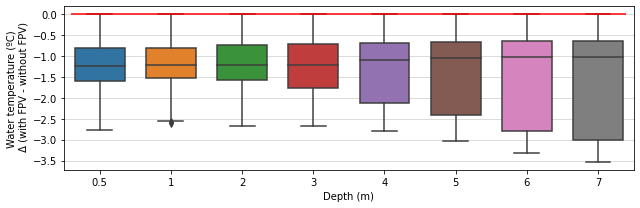

In [22]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3])
pal = sns.color_palette("tab10",10)
depths = WT_bias_boxplot_underFPV['depth'].unique().tolist()

sns.boxplot(x = "depth", y = "bias", 
            data = WT_bias_boxplot_underFPV.loc[WT_bias_boxplot_underFPV['depth'].isin(depths)],
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[0:9], ax = ax)

ax.set_xticks([0,1,2,3,4,5,6,7], depths, fontsize = 10)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
       
ax.yaxis.set_label_text(u'Water temperature (ºC)\n Δ (with FPV - without FPV)', fontsize = 10)
ax.xaxis.set_label_text(u'Depth (m)', fontsize = 10)

ax.hlines(y = 0, xmin = -0.4, xmax = 7.4, color = 'r')
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'WT_boxplot_bias.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

In [43]:
bias_underFPV_plot_reduced = WT_bias_underFPV[['bias_underFPV_0.5m', 'bias_underFPV_1m', 
                                               'bias_underFPV_3m', 'bias_underFPV_4m',
                                               'bias_underFPV_6m', 'bias_underFPV_7m']].copy()
bias_underFPV_plot_reduced.head(2)

,bias_underFPV_0.5m,bias_underFPV_1m,bias_underFPV_3m,bias_underFPV_4m,bias_underFPV_6m,bias_underFPV_7m
time,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.005075,0.004908,0.004371,0.003994,0.000348,-0.000568


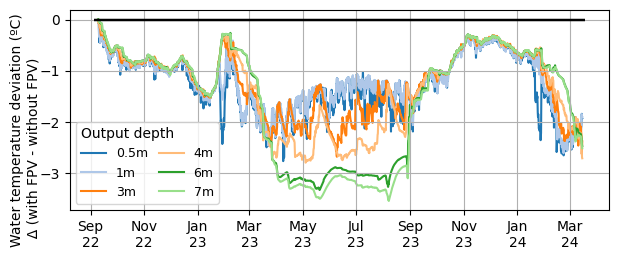

In [104]:
bias_underFPV_plot_df = bias_underFPV_plot_reduced.copy()

# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,2.7])
pal = sns.color_palette("tab20", 6)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

legends = ['0.5m', '1m', '3m', '4m', '6m', '7m']

for depth in range(0, len(bias_underFPV_plot_df.columns), 1):
    ax.plot(bias_underFPV_plot_df.index, bias_underFPV_plot_df[bias_underFPV_plot_df.columns[depth]],
            color = pal.as_hex()[depth], zorder = 1, label = legends[depth])
    ax.hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Output depth", loc="lower left", ncol = 2, fontsize = 9, 
               frameon = True, columnspacing = 0.85)._legend_box.align = "left"

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9],
#               ['Sep\n22', 'Nov\n22', 'Jan\n23', 'Mar\n23',
#                'May\n23', 'Jul\n23', 'Sep\n23',
#                'Nov\n23', 'Jan\n24', 'Mar\n24'],
#               fontsize = 10)

# ax.set_ylim(-0.5,0.6)

myFmt = mdates.DateFormatter('%b\n%y') # date format with month in string!
ax.xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Water temperature deviation (ºC)\n  Δ (with FPV - without FPV)', va='center', rotation='vertical')
 
plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'WT_timeseries_bias_reduced.jpeg', dpi=600, bbox_inches='tight')

plt.show();

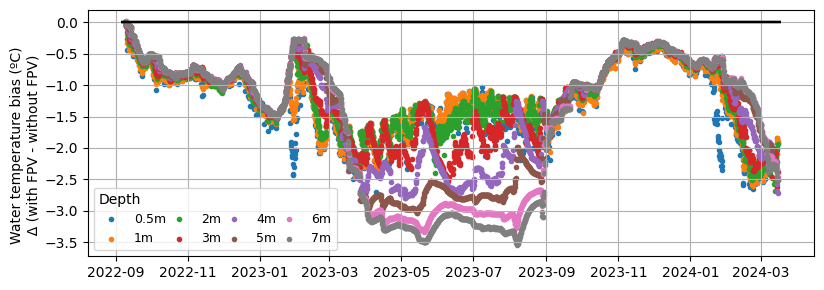

In [23]:
bias_underFPV_plot_df = WT_bias_underFPV.copy()

# Plot graph with bias per depth
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [8,3])
pal = sns.color_palette("tab10", 11)
# ax[0].get_xlim()[0] # line to check xaxis limits (0 - start, -1 - end)

legends = ['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m', '8m']

for depth in range(0, len(bias_underFPV_plot_df.columns), 1):
    ax.scatter(bias_underFPV_plot_df.index, bias_underFPV_plot_df[bias_underFPV_plot_df.columns[depth]],
                  marker = '.', color = pal.as_hex()[depth], zorder = 1,
                  label = legends[depth])
    ax.hlines(y = 0, xmin = 19240, xmax = 19800, color = 'k')
    ax.grid(True, zorder = -1)

ax.legend(title = "Depth", loc="lower left", ncol = 4, fontsize = 9, 
               frameon = True, columnspacing = 0.01)._legend_box.align = "left"

# ax.set_ylim(-0.5,0.6)

plt.subplots_adjust(wspace = 0, hspace = 0)

fig.text(-0.024, 0.5, u'Water temperature bias (ºC)\n  Δ (with FPV - without FPV)', va='center', rotation='vertical')
 
plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'WT_timeseries_bias.jpeg', dpi=600, bbox_inches='tight')

plt.show();

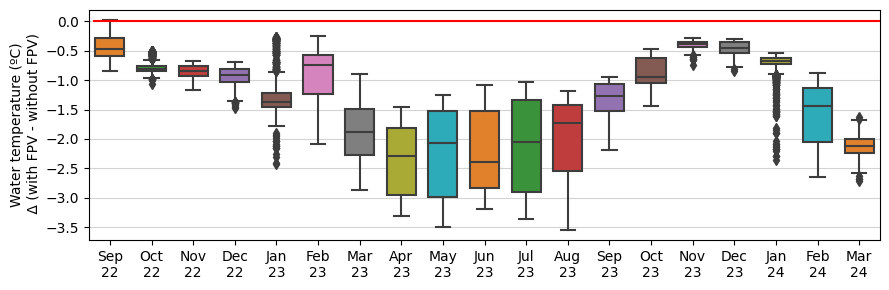

In [181]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3], sharey = True)

pal = sns.color_palette("tab10",10)

# CAB location
sns.boxplot(x = "month_str", y = "bias", data = WT_bias_boxplot_underFPV,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:10], ax = ax)

ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
              ['Sep\n22','Oct\n22', 'Nov\n22', 'Dec\n22','Jan\n23', 'Feb\n23', 'Mar\n23','Apr\n23', 'May\n23', 'Jun\n23',
              'Jul\n23', 'Aug\n23', 'Sep\n23', 'Oct\n23', 'Nov\n23', 'Dec\n23', 'Jan\n24', 'Feb\n24','Mar\n24'],
              fontsize = 10)

# ax.set_ylim(-1.5,1.5)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Water temperature (ºC)\n Δ (with FPV - without FPV)', fontsize = 10)

# ax.legend(title = "Output source", loc="upper right", ncol = 2, fontsize = 10, 
#           frameon = True, columnspacing = 1)._legend_box.align = "left"
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')
ax.set(xlabel=None)

ax.hlines(y = 0, xmin = -0.4, xmax = 18.5, color = 'r')

# ax.text(-0.3, 20, '(a) CAB location', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
plt.savefig(figs_path + 'WT_boxplot_bias_monthly.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

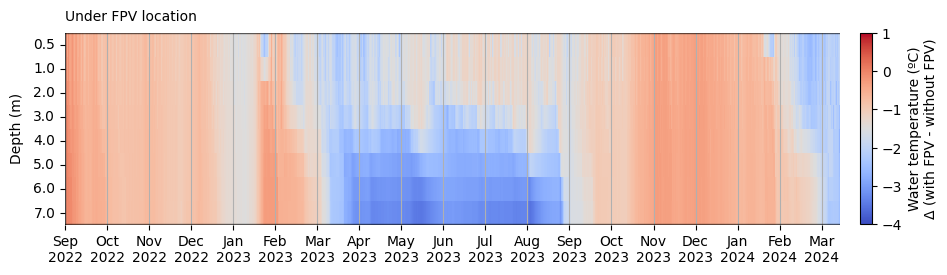

In [193]:
# Plot heatmap for temperature data
fig, ax = plt.subplots(1, 1, figsize = (10,2.5), sharex = True, sharey = True)

# Under FPV location
g = sns.heatmap(WT_bias_heatmap_underFPV_pivot, square = False, linewidth = None, linecolor = None, ax = ax,
                xticklabels = 120, yticklabels = 1, cmap = 'coolwarm', cbar = False, 
                vmin = -4, vmax = 1)

g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 10)
g.set_yticklabels(g.get_ymajorticklabels(), rotation = 0, fontsize = 10)

ax.set_ylabel('')
ax.text(0, -0.5, 'Under FPV location', 
                  color = 'k', fontsize = 10)

ax.figure.axes[-1].yaxis.label.set_size(10)
ax.grid(axis = 'x')
ax.axhline(y = 0, color = 'k',linewidth = 1, alpha = 0.6)
ax.axvline(x = 0, color = 'k', linewidth = 1, alpha = 0.6)

# Adds frame to heatmap plot
ax.axhline(y = 7.95, color='k', linewidth = 1, alpha = 0.6)

# Creates new colorbar and set font sizes
divider = make_axes_locatable(ax)
cax = fig.add_axes([0.92, 0.114, 0.012, 0.765]) # x, y, width, height
cbar = fig.colorbar(ax.collections[0], cax = cax)
cbar.ax.tick_params(labelsize = 10)
cbar.set_label(u'Water temperature (ºC)\nΔ (with FPV - without FPV)', size = 10)

fig.text(0.07, 0.5, u'Depth (m)', fontsize = 10, va='center', rotation='vertical')

# Salvar o gráfico gerado
plt.savefig(figs_path + 'WT_heatmap_underFPVloc.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

# Potential Energy Anomaly

## No FPV run

### Under FPV location

In [22]:
# Opens delft output and extracts variables of interest
temp_noFPV_underFPV = xr.open_dataset(no_fpv_run[0])
temp_noFPV_underFPV = temp_noFPV_underFPV[["RHO", "ZK_LYR", "ZK", "S1"]].isel(M = 20, N = 32)
temp_noFPV_underFPV["DK_LYR"] = temp_noFPV_underFPV.S1 - temp_noFPV_underFPV.ZK_LYR
temp_noFPV_underFPV["DK"] = temp_noFPV_underFPV.S1 - temp_noFPV_underFPV.ZK

# creates df with rho and respective depth
for i in range(len(temp_noFPV_underFPV.time.values)):
    temp = temp_noFPV_underFPV.isel(time = i) # subsets for timestep analysed
    depth = temp.DK_LYR.values # gets depth values
    max_depth = temp.DK.values # gets max depth values (at cell interface rather than centre)
    rho = temp.RHO.values # gets rho values
    rho = rho[depth > 0] # subsets for active layers
    depth = depth[depth > 0] # subsets for active layers
    
    temp_df = pd.DataFrame(depth, columns = ['depth_from_surface'])
    temp_df['max_depth'] = pd.DataFrame(max_depth)
    temp_df['rho_noFPV_underFPV'] = pd.DataFrame(rho)
    temp_df['time'] = temp.time.values
    temp_df.set_index('time', inplace = True)
    
    if i == 0:
        rho_underFPV_noFPV = temp_df.copy()
    else:
        rho_underFPV_noFPV = pd.concat([rho_underFPV_noFPV, temp_df])
    
rho_underFPV_noFPV['month'] = rho_underFPV_noFPV.index.month
rho_underFPV_noFPV['year'] = rho_underFPV_noFPV.index.year
rho_underFPV_noFPV['year'] = rho_underFPV_noFPV['year'].apply(lambda x: str(x)[2:])
rho_underFPV_noFPV['month_str'] = ((rho_underFPV_noFPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                   (rho_underFPV_noFPV['year']))
rho_underFPV_noFPV.drop(['month','year'], axis = 1, inplace = True)
rho_underFPV_noFPV.head(2)

,depth_from_surface,max_depth,rho_noFPV_underFPV,month_str
time,,,,
2022-09-09,7.575625,8.50000,997.598755,Sep22
2022-09-09,6.189062,6.65125,997.505432,Sep22


In [23]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

days_noFPV = rho_underFPV_noFPV.index.unique()

for day in range(0, len(days_noFPV), 1):
    temporary = rho_underFPV_noFPV.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_noFPV[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_noFPV_underFPV'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_noFPV_underFPV']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (1 / (temporary.iloc[0,1])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_noFPV_underFPV'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_noFPV_underFPV = temp_df
    else:
        PEA_noFPV_underFPV = pd.concat([PEA_noFPV_underFPV, temp_df])

PEA_noFPV_underFPV.set_index('time', inplace = True)

# Creates columns with month
PEA_noFPV_underFPV['month'] = PEA_noFPV_underFPV.index.month
PEA_noFPV_underFPV['year'] = PEA_noFPV_underFPV.index.year
PEA_noFPV_underFPV['year'] = PEA_noFPV_underFPV['year'].apply(lambda x: str(x)[2:])
PEA_noFPV_underFPV['month_str'] = ((PEA_noFPV_underFPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                   (PEA_noFPV_underFPV['year']))
PEA_noFPV_underFPV.drop('year', axis = 1, inplace = True)
PEA_noFPV_underFPV.head(2)

,PEA_noFPV_underFPV,month,month_str
time,,,
2022-09-09 00:00:00,1.488557,9,Sep22
2022-09-09 06:00:00,0.665585,9,Sep22


### Open water location

In [24]:
# Opens delft output and extracts variables of interest
temp_noFPV_openwater = xr.open_dataset(no_fpv_run[0])
temp_noFPV_openwater = temp_noFPV_openwater[["RHO", "ZK_LYR", "ZK", "S1"]].isel(M = 38, N = 11)
temp_noFPV_openwater["DK_LYR"] = temp_noFPV_openwater.S1 - temp_noFPV_openwater.ZK_LYR
temp_noFPV_openwater["DK"] = temp_noFPV_openwater.S1 - temp_noFPV_openwater.ZK

# creates df with rho and respective depth
for i in range(len(temp_noFPV_openwater.time.values)):
    temp = temp_noFPV_openwater.isel(time = i) # subsets for timestep analysed
    depth = temp.DK_LYR.values # gets depth values
    max_depth = temp.DK.values # gets max depth values (at cell interface rather than centre)
    rho = temp.RHO.values # gets rho values
    rho = rho[depth > 0] # subsets for active layers
    depth = depth[depth > 0] # subsets for active layers
    
    temp_df = pd.DataFrame(depth, columns = ['depth_from_surface'])
    temp_df['max_depth'] = pd.DataFrame(max_depth)
    temp_df['rho_noFPV_openwater'] = pd.DataFrame(rho)
    temp_df['time'] = temp.time.values
    temp_df.set_index('time', inplace = True)
    
    if i == 0:
        rho_openwater_noFPV = temp_df.copy()
    else:
        rho_openwater_noFPV = pd.concat([rho_openwater_noFPV, temp_df])
    
rho_openwater_noFPV['month'] = rho_openwater_noFPV.index.month
rho_openwater_noFPV['year'] = rho_openwater_noFPV.index.year
rho_openwater_noFPV['year'] = rho_openwater_noFPV['year'].apply(lambda x: str(x)[2:])
rho_openwater_noFPV['month_str'] = ((rho_openwater_noFPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                    (rho_openwater_noFPV['year']))
rho_openwater_noFPV.drop(['month','year'], axis = 1, inplace = True)
rho_openwater_noFPV.head(2)

,depth_from_surface,max_depth,rho_noFPV_openwater,month_str
time,,,,
2022-09-09,7.575625,8.50000,997.598755,Sep22
2022-09-09,6.189062,6.65125,997.505432,Sep22


In [25]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

days_noFPV = rho_openwater_noFPV.index.unique()

for day in range(0, len(days_noFPV), 1):
    temporary = rho_openwater_noFPV.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_noFPV[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_noFPV_openwater'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_noFPV_openwater']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (1 / (temporary.iloc[0,1])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_noFPV_openwater'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_noFPV_openwater = temp_df
    else:
        PEA_noFPV_openwater = pd.concat([PEA_noFPV_openwater, temp_df])

PEA_noFPV_openwater.set_index('time', inplace = True)

# Creates columns with month
PEA_noFPV_openwater['month'] = PEA_noFPV_openwater.index.month
PEA_noFPV_openwater['year'] = PEA_noFPV_openwater.index.year
PEA_noFPV_openwater['year'] = PEA_noFPV_openwater['year'].apply(lambda x: str(x)[2:])
PEA_noFPV_openwater['month_str'] = ((PEA_noFPV_openwater['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                    (PEA_noFPV_openwater['year']))
PEA_noFPV_openwater.drop('year', axis = 1, inplace = True)
PEA_noFPV_openwater.head(2)

,PEA_noFPV_openwater,month,month_str
time,,,
2022-09-09 00:00:00,1.488557,9,Sep22
2022-09-09 06:00:00,0.661842,9,Sep22


### no FPV dataframe - both locations

In [26]:
# Creates dataframe for PEA with both locations - SIMULATION WITHOUT FPV
PEA_noFPV = PEA_noFPV_underFPV.merge(PEA_noFPV_openwater, on = ['time','month', 'month_str'], how = 'inner')
PEA_noFPV = PEA_noFPV[['month', 'month_str', 'PEA_noFPV_underFPV', 'PEA_noFPV_openwater']]
PEA_noFPV.head(2)

,month,month_str,PEA_noFPV_underFPV,PEA_noFPV_openwater
time,,,,
2022-09-09 00:00:00,9,Sep22,1.488557,1.488557
2022-09-09 06:00:00,9,Sep22,0.665585,0.661842


## FPV 49% coverage run

### Under FPV location

In [27]:
# Opens delft output and extracts variables of interest
temp_FPV_underFPV = xr.open_dataset(fpv_run[0])
temp_FPV_underFPV = temp_FPV_underFPV[["RHO", "ZK_LYR", "ZK", "S1"]].isel(M = 20, N = 32)
temp_FPV_underFPV["DK_LYR"] = temp_FPV_underFPV.S1 - temp_FPV_underFPV.ZK_LYR
temp_FPV_underFPV["DK"] = temp_FPV_underFPV.S1 - temp_FPV_underFPV.ZK

# creates df with rho and respective depth
for i in range(len(temp_FPV_underFPV.time.values)):
    temp = temp_FPV_underFPV.isel(time = i) # subsets for timestep analysed
    depth = temp.DK_LYR.values # gets depth values
    max_depth = temp.DK.values # gets max depth values (at cell interface rather than centre)
    rho = temp.RHO.values # gets rho values
    rho = rho[depth > 0] # subsets for active layers
    depth = depth[depth > 0] # subsets for active layers
    
    temp_df = pd.DataFrame(depth, columns = ['depth_from_surface'])
    temp_df['max_depth'] = pd.DataFrame(max_depth)
    temp_df['rho_FPV_underFPV'] = pd.DataFrame(rho)
    temp_df['time'] = temp.time.values
    temp_df.set_index('time', inplace = True)
    
    if i == 0:
        rho_underFPV_FPV = temp_df.copy()
    else:
        rho_underFPV_FPV = pd.concat([rho_underFPV_FPV, temp_df])
    
rho_underFPV_FPV['month'] = rho_underFPV_FPV.index.month
rho_underFPV_FPV['year'] = rho_underFPV_FPV.index.year
rho_underFPV_FPV['year'] = rho_underFPV_FPV['year'].apply(lambda x: str(x)[2:])
rho_underFPV_FPV['month_str'] = ((rho_underFPV_FPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                 (rho_underFPV_FPV['year']))
rho_underFPV_FPV.drop(['month','year'], axis = 1, inplace = True)
rho_underFPV_FPV.head(2)

,depth_from_surface,max_depth,rho_FPV_underFPV,month_str
time,,,,
2022-09-09,7.575625,8.50000,997.598755,Sep22
2022-09-09,6.189062,6.65125,997.505432,Sep22


In [28]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

days_FPV = rho_underFPV_FPV.index.unique()

for day in range(0, len(days_FPV), 1):
    temporary = rho_underFPV_FPV.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_FPV[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_FPV_underFPV'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_FPV_underFPV']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (1 / (temporary.iloc[0,1])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_FPV_underFPV'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_FPV_underFPV = temp_df.copy()
    else:
        PEA_FPV_underFPV = pd.concat([PEA_FPV_underFPV, temp_df])

PEA_FPV_underFPV.set_index('time', inplace = True)

# Creates columns with month
PEA_FPV_underFPV['month'] = PEA_FPV_underFPV.index.month
PEA_FPV_underFPV['year'] = PEA_FPV_underFPV.index.year
PEA_FPV_underFPV['year'] = PEA_FPV_underFPV['year'].apply(lambda x: str(x)[2:])
PEA_FPV_underFPV['month_str'] = ((PEA_FPV_underFPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                 (PEA_FPV_underFPV['year']))
PEA_FPV_underFPV.drop('year', axis = 1, inplace = True)
PEA_FPV_underFPV.head(2)

,PEA_FPV_underFPV,month,month_str
time,,,
2022-09-09 00:00:00,1.488557,9,Sep22
2022-09-09 06:00:00,0.670527,9,Sep22


### Open water location

In [29]:
# Opens delft output and extracts variables of interest
temp_FPV_openwater = xr.open_dataset(fpv_run[0])
temp_FPV_openwater = temp_FPV_openwater[["RHO", "ZK_LYR", "ZK", "S1"]].isel(M = 38, N = 11)
temp_FPV_openwater["DK_LYR"] = temp_FPV_openwater.S1 - temp_FPV_openwater.ZK_LYR
temp_FPV_openwater["DK"] = temp_FPV_openwater.S1 - temp_FPV_openwater.ZK

# creates df with rho and respective depth
for i in range(len(temp_FPV_openwater.time.values)):
    temp = temp_FPV_openwater.isel(time = i) # subsets for timestep analysed
    depth = temp.DK_LYR.values # gets depth values
    max_depth = temp.DK.values # gets max depth values (at cell interface rather than centre)
    rho = temp.RHO.values # gets rho values
    rho = rho[depth > 0] # subsets for active layers
    depth = depth[depth > 0] # subsets for active layers
    
    temp_df = pd.DataFrame(depth, columns = ['depth_from_surface'])
    temp_df['max_depth'] = pd.DataFrame(max_depth)
    temp_df['rho_FPV_openwater'] = pd.DataFrame(rho)
    temp_df['time'] = temp.time.values
    temp_df.set_index('time', inplace = True)
    
    if i == 0:
        rho_openwater_FPV = temp_df.copy()
    else:
        rho_openwater_FPV = pd.concat([rho_openwater_FPV, temp_df])
    
rho_openwater_FPV['month'] = rho_openwater_FPV.index.month
rho_openwater_FPV['year'] = rho_openwater_FPV.index.year
rho_openwater_FPV['year'] = rho_openwater_FPV['year'].apply(lambda x: str(x)[2:])
rho_openwater_FPV['month_str'] = ((rho_openwater_FPV['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                  (rho_openwater_FPV['year']))
rho_openwater_FPV.drop(['month','year'], axis = 1, inplace = True)
rho_openwater_FPV.head(2)

,depth_from_surface,max_depth,rho_FPV_openwater,month_str
time,,,,
2022-09-09,7.575625,8.50000,997.598755,Sep22
2022-09-09,6.189062,6.65125,997.505432,Sep22


In [30]:
## Calculates PEA
# One loop does calculations for every day and time from model output
# The other loop reads every scenario simulated
g = 9.81

days_FPV = rho_openwater_FPV.index.unique()

for day in range(0, len(days_FPV), 1):
    temporary = rho_openwater_FPV.copy()
    # subsets df according to analysed day
    temporary = temporary.loc[temporary.index == days_FPV[day]]
    # calculates modelled layer depth
    temporary['delta_depth'] = temporary['depth_from_surface'].diff()
    # takes out na rows from depth diff
    temporary = temporary[temporary['delta_depth'].isna() == False]
    # estimates weight-averaged density for the water column
    mean_rho = ((temporary['rho_FPV_openwater'] * 
                 temporary['delta_depth']).sum())/(temporary['delta_depth'].sum())
    # PEA calculation
    temporary['to_sum'] = ((mean_rho - temporary['rho_FPV_openwater']) *
                           g * temporary['depth_from_surface'] * temporary['delta_depth'])
    PEA = (1 / (temporary.iloc[0,1])) * (temporary['to_sum'].sum())
    # creates a new df with time and PEA
    temp_df = pd.DataFrame([temporary.index[0], PEA]).T
    temp_df.rename(columns = 
                   {temp_df.columns[0]:'time', 
                    temp_df.columns[1]:'PEA_FPV_openwater'}, inplace = True)
    # concatenates estimated PEA's into one df
    if day == 0:
        PEA_FPV_openwater = temp_df.copy()
    else:
        PEA_FPV_openwater = pd.concat([PEA_FPV_openwater, temp_df])

PEA_FPV_openwater.set_index('time', inplace = True)

# Creates columns with month
PEA_FPV_openwater['month'] = PEA_FPV_openwater.index.month
PEA_FPV_openwater['year'] = PEA_FPV_openwater.index.year
PEA_FPV_openwater['year'] = PEA_FPV_openwater['year'].apply(lambda x: str(x)[2:])
PEA_FPV_openwater['month_str'] = ((PEA_FPV_openwater['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                  (PEA_FPV_openwater['year']))
PEA_FPV_openwater.drop('year', axis = 1, inplace = True)
PEA_FPV_openwater.head(2)

,PEA_FPV_openwater,month,month_str
time,,,
2022-09-09 00:00:00,1.488557,9,Sep22
2022-09-09 06:00:00,0.667151,9,Sep22


### FPV 49% coverage dataframe - both locations

In [31]:
# Creates dataframe for PEA with both locations - SIMULATION WITHOUT FPV
PEA_FPV = PEA_FPV_underFPV.merge(PEA_FPV_openwater, on = ['time','month', 'month_str'], how = 'inner')
PEA_FPV = PEA_FPV[['month', 'month_str', 'PEA_FPV_underFPV', 'PEA_FPV_openwater']]
PEA_FPV.head(2)

,month,month_str,PEA_FPV_underFPV,PEA_FPV_openwater
time,,,,
2022-09-09 00:00:00,9,Sep22,1.488557,1.488557
2022-09-09 06:00:00,9,Sep22,0.670527,0.667151


## PEA - Quantitative comparison

In [32]:
# Join all data into one dataframe
PEA_compare = PEA_noFPV.copy()
PEA_compare = PEA_compare.merge(PEA_FPV, on = ['time', 'month', 'month_str'], how = 'inner')
PEA_compare.head(2)

,month,month_str,PEA_noFPV_underFPV,PEA_noFPV_openwater,PEA_FPV_underFPV,PEA_FPV_openwater
time,,,,,,
2022-09-09 00:00:00,9,Sep22,1.488557,1.488557,1.488557,1.488557
2022-09-09 06:00:00,9,Sep22,0.665585,0.661842,0.670527,0.667151


In [33]:
# Separate dfs for two locations: under FPV and open water
PEA_comp_underFPV = PEA_compare[['month', 'month_str', 'PEA_noFPV_underFPV', 'PEA_FPV_underFPV']]
PEA_comp_openwater = PEA_compare[['month', 'month_str', 'PEA_noFPV_openwater', 'PEA_FPV_openwater']]

## Metrics - PEA

Under FPV location

In [57]:
# Calculates metrics for each depth
metrics_PEA_underFPV = PEA_comp_underFPV.copy()
n = len(metrics_PEA_underFPV)
r2_PEA_underFPV = ((np.corrcoef(metrics_PEA_underFPV[metrics_PEA_underFPV.columns[2]].astype(float), 
                           metrics_PEA_underFPV[metrics_PEA_underFPV.columns[3]].astype(float))[0,1]) ** 2)
metrics_PEA_underFPV['sq_error'] = ((metrics_PEA_underFPV[metrics_PEA_underFPV.columns[3]] - 
                                     metrics_PEA_underFPV[metrics_PEA_underFPV.columns[2]]) ** 2)
RMSE_PEA_underFPV = (((1/n) * (metrics_PEA_underFPV['sq_error'].sum()) ) ** 0.5)
bias_PEA_underFPV = (((metrics_PEA_underFPV[metrics_PEA_underFPV.columns[3]] - 
                  metrics_PEA_underFPV[metrics_PEA_underFPV.columns[2]]).sum()) / n)

print('r² (PEA under FPV location):', r2_PEA_underFPV)
print('')
print('RMSE (PEA under FPV location):', RMSE_PEA_underFPV)
print('')
print('Bias: (PEA under FPV location)', bias_PEA_underFPV)

r² (PEA under FPV location): 0.9588154910677031

RMSE (PEA under FPV location): 1.654235916390658

Bias: (PEA under FPV location) 0.6045676260569184


Open water location

In [58]:
# Calculates metrics for each depth
metrics_PEA_openwater = PEA_comp_openwater.copy()
n = len(metrics_PEA_openwater)
r2_PEA_openwater = ((np.corrcoef(metrics_PEA_openwater[metrics_PEA_openwater.columns[2]].astype(float), 
                                 metrics_PEA_openwater[metrics_PEA_openwater.columns[3]].astype(float))[0,1]) ** 2)
metrics_PEA_openwater['sq_error'] = ((metrics_PEA_openwater[metrics_PEA_openwater.columns[3]] - 
                                      metrics_PEA_openwater[metrics_PEA_openwater.columns[2]]) ** 2)
RMSE_PEA_openwater = (((1/n) * (metrics_PEA_openwater['sq_error'].sum()) ) ** 0.5)
bias_PEA_openwater = (((metrics_PEA_openwater[metrics_PEA_openwater.columns[3]] - 
                        metrics_PEA_openwater[metrics_PEA_openwater.columns[2]]).sum()) / n)

print('r² (PEA open water location):', r2_PEA_openwater)
print('')
print('RMSE (PEA open water location):', RMSE_PEA_openwater)
print('')
print('Bias: (PEA open water location)', bias_PEA_openwater)

r² (PEA open water location): 0.9588513807498134

RMSE (PEA open water location): 1.6578326843089837

Bias: (PEA open water location) 0.6086656219145018


## PEA - plots

### Time series

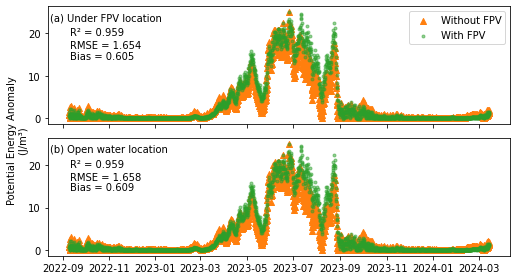

In [38]:
# Plot model x measured for depth
# Plot time series - hourly data
# ax.get_xlim()[0]

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,4], sharex = True, sharey = True)

pal = sns.color_palette("tab10", 5) # set color range

# Under FPV location
ax[0].scatter(PEA_comp_underFPV.index, PEA_comp_underFPV['PEA_noFPV_underFPV'], marker = '^', 
              label = 'Without FPV', color = pal.as_hex()[1])
ax[0].scatter(PEA_comp_underFPV.index, PEA_comp_underFPV['PEA_FPV_underFPV'], marker = '.', 
              label = 'With FPV', color = pal.as_hex()[2], alpha = 0.5)

ax[0].text(19245, 19.5, 'R² = %0.3f' % r2_PEA_underFPV, color = 'k', fontsize = 10)
ax[0].text(19245, 16.5, 'RMSE = %0.3f' % RMSE_PEA_underFPV, color = 'k', fontsize = 10)
ax[0].text(19245, 14, 'Bias = %0.3f' % bias_PEA_underFPV, color = 'k', fontsize = 10)

ax[0].text(19220, 23, '(a) Under FPV location', color = 'k', fontsize = 10)

# Add legends
ax[0].legend(loc = 'upper right')

# Open water location
ax[1].scatter(PEA_comp_openwater.index, PEA_comp_openwater['PEA_noFPV_openwater'], marker = '^', 
              label = 'Without FPV', color = pal.as_hex()[1])
ax[1].scatter(PEA_comp_openwater.index, PEA_comp_openwater['PEA_FPV_openwater'], marker = '.', 
              label = 'With FPV', color = pal.as_hex()[2], alpha = 0.5)

ax[1].text(19245, 19.5, 'R² = %0.3f' % r2_PEA_openwater, color = 'k', fontsize = 10)
ax[1].text(19245, 16.5, 'RMSE = %0.3f' % RMSE_PEA_openwater, color = 'k', fontsize = 10)
ax[1].text(19245, 14, 'Bias = %0.3f' % bias_PEA_openwater, color = 'k', fontsize = 10)

ax[1].text(19220, 23, '(b) Open water location', color = 'k', fontsize = 10)

# ax.set_ylim(7,10)

# Add formatted date labels
# xlabels = ['Sep 22','Nov 22', 'Jan 23', 'Mar 23','May 23', 'Jul 23', 'Sep 23','Nov 23', 'Jan 24', 'Mar 24']
# xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
# ax.set_xticklabels(xlabels_new)

# Plot settings
fig.text(-0.02, 0.5, 'Potential Energy Anomaly\n                (J/m³)', va = 'center', rotation = 'vertical')
# fig.subplots_adjust(top = 0.94)

plt.tight_layout()

# Save graph;
plt.savefig(figs_path + 'PEA_ts_FPV_qgrid.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

### Histogram

In [39]:
## Creates df with only PEA data to compare
# Under FPV location
histogram_PEA_underFPV = PEA_comp_underFPV[PEA_comp_underFPV.columns[[2,3]]]

# Open water location
histogram_PEA_openwater = PEA_comp_openwater[PEA_comp_openwater.columns[[2,3]]]
histogram_PEA_openwater.head(2)

,PEA_noFPV_openwater,PEA_FPV_openwater
time,,
2022-09-09 00:00:00,1.488557,1.488557
2022-09-09 06:00:00,0.661842,0.667151


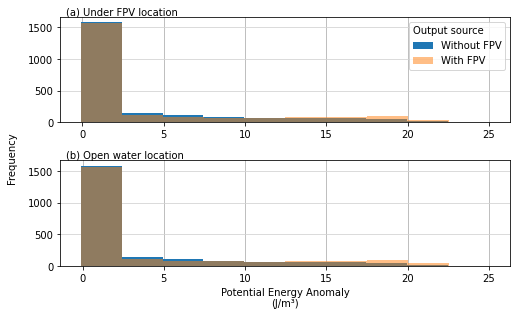

In [40]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,4.5], sharey = True)

# Under FPV location
histogram_PEA_underFPV['PEA_noFPV_underFPV'].hist(ax = ax[0], label = 'Without FPV')
histogram_PEA_underFPV['PEA_FPV_underFPV'].hist(ax = ax[0], label = 'With FPV', alpha = 0.5)

ax[0].set_axisbelow(True)
ax[0].grid(color='lightgray', axis = 'y')

ax[0].legend(title = "Output source", loc="upper right", ncol = 1, fontsize = 10, 
             frameon = True, columnspacing = 1)._legend_box.align = "left"

ax[0].text(-1, 1700, '(a) Under FPV location', color = 'k', fontsize = 10)

# Open water location
histogram_PEA_openwater['PEA_noFPV_openwater'].hist(ax = ax[1], label = 'Without FPV')
histogram_PEA_openwater['PEA_FPV_openwater'].hist(ax = ax[1], label = 'With FPV', alpha = 0.5)

ax[1].xaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)

ax[1].set_axisbelow(True)
ax[1].grid(color='lightgray', axis = 'y')

ax[1].text(-1, 1700, '(b) Open water location', color = 'k', fontsize = 10)

fig.text(-0.02, 0.5, 'Frequency', va = 'center', rotation = 'vertical')

plt.tight_layout() # Para ajustar melhor os gráficos
# plt.rcdefaults()
plt.savefig(figs_path + 'PEA_histogram_FPV_eqgrid.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

### Boxplot

In [34]:
# Creates a single df to plot boxplot with CAB and BIS locations into one plot
## Under FPV location
joined_df_PEA_underFPV = PEA_compare[PEA_compare.columns[[0,1,2]]]
joined_df_PEA_underFPV.rename(columns = {'PEA_noFPV_underFPV':'PEA'}, inplace = True)
joined_df_PEA_underFPV.reset_index(drop = True, inplace = True)
joined_df_PEA_underFPV['Point location'] = 'Under FPV'
joined_df_PEA_underFPV['Simulation'] = 'Without FPV'

temp_df_PEA_underFPV = PEA_compare[PEA_compare.columns[[0,1,4]]]
temp_df_PEA_underFPV.rename(columns = {'PEA_FPV_underFPV':'PEA'}, inplace = True)
temp_df_PEA_underFPV.reset_index(drop = True, inplace = True)
temp_df_PEA_underFPV['Point location'] = 'Under FPV'
temp_df_PEA_underFPV['Simulation'] = 'With FPV'

PEA_boxplot_underFPV = pd.concat([joined_df_PEA_underFPV, temp_df_PEA_underFPV])

# Add open water location
joined_df_PEA_openwater = PEA_compare[PEA_compare.columns[[0,1,3]]]
joined_df_PEA_openwater.rename(columns = {'PEA_noFPV_openwater':'PEA'}, inplace = True)
joined_df_PEA_openwater.reset_index(drop = True, inplace = True)
joined_df_PEA_openwater['Point location'] = 'Open water'
joined_df_PEA_openwater['Simulation'] = 'Without FPV'

temp_df_PEA_openwater = PEA_compare[PEA_compare.columns[[0,1,5]]]
temp_df_PEA_openwater.rename(columns = {'PEA_FPV_openwater':'PEA'}, inplace = True)
temp_df_PEA_openwater.reset_index(drop = True, inplace = True)
temp_df_PEA_openwater['Point location'] = 'Open water'
temp_df_PEA_openwater['Simulation'] = 'With FPV'

PEA_boxplot_openwater = pd.concat([joined_df_PEA_openwater, temp_df_PEA_openwater])

# Join dfs
PEA_boxplot = PEA_boxplot_underFPV.copy()
PEA_boxplot = pd.concat([PEA_boxplot_underFPV, PEA_boxplot_openwater])
PEA_boxplot.head(2)

<ipython-input-34-2fa4afae99be>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_df_PEA_underFPV.rename(columns = {'PEA_noFPV_underFPV':'PEA'}, inplace = True)
<ipython-input-34-2fa4afae99be>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_df_PEA_underFPV['Point location'] = 'Under FPV'
<ipython-input-34-2fa4afae99be>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

,month,month_str,PEA,Point location,Simulation
0,9,Sep22,1.488557,Under FPV,Without FPV
1,9,Sep22,0.665585,Under FPV,Without FPV


In [35]:
# Split by location to make seasonal/monthly analysis
PEA_boxplot_df_underFPV = PEA_boxplot[PEA_boxplot['Point location'] == 'Under FPV']
PEA_boxplot_df_underFPV.rename(columns = {'month_str':'Month'}, inplace = True)

PEA_boxplot_df_openwater = PEA_boxplot[PEA_boxplot['Point location'] == 'Open water']
PEA_boxplot_df_openwater.rename(columns = {'month_str':'Month'}, inplace = True)

<ipython-input-35-2f8a3e6af712>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PEA_boxplot_df_underFPV.rename(columns = {'month_str':'Month'}, inplace = True)
<ipython-input-35-2f8a3e6af712>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PEA_boxplot_df_openwater.rename(columns = {'month_str':'Month'}, inplace = True)


In [37]:
PEA_boxplot_df_underFPV.to_csv('PEA_boxplot_df_underFPV.csv')

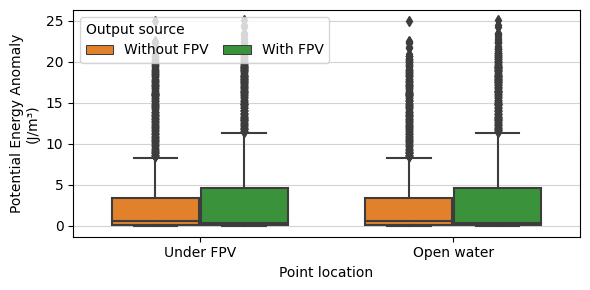

In [61]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,3])

pal = sns.color_palette("tab10",5)
# depths = joined_df_boxplot['depth'].unique().tolist()

sns.boxplot(x = "Point location", y = "PEA", 
            data = PEA_boxplot,
            width = 0.7, boxprops = {'zorder': 1}, 
            palette = pal[1:3], ax = ax, hue = 'Simulation')

# ax.set_xticks([0,1,2,3,4,5,6,7,8,9], depths,
#               fontsize = 10)

# ax.set_ylim(-2,19)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
       
ax.yaxis.set_label_text(u'Potential Energy Anomaly\n(J/m³)', fontsize = 10)

ax.legend(title = "Output source", loc="upper left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"

# ax.hlines(y = 0, xmin = 0, xmax = 9, color = 'r')
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

plt.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'PEA_boxplots_FPV_eqgrid.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

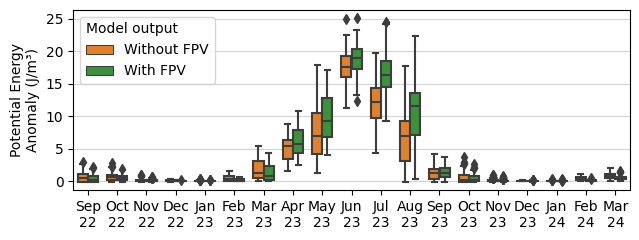

In [107]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6.5,2.5], sharex = True, sharey = True)

pal = sns.color_palette("tab10",5)

# Under FPV location
sns.boxplot(x = "Month", y = "PEA", data = PEA_boxplot_df_underFPV,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax, hue = 'Simulation')

# ax[0].set_ylim(-2,21)
ax.tick_params(axis = 'y', which = 'major', labelsize = 10)
ax.yaxis.set_label_text(u'Potential Energy\nAnomaly (J/m³)', fontsize = 10)

ax.legend(title = "Model output", loc="upper left", ncol = 1, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"
ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y', zorder=0)

ax.set(xlabel=None)

ax.set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
              ['Sep\n22', 'Oct\n22', 'Nov\n22', 'Dec\n22', 'Jan\n23', 'Feb\n23', 'Mar\n23',
               'Apr\n23', 'May\n23', 'Jun\n23', 'Jul\n23', 'Aug\n23', 'Sep\n23', 'Oct\n23',
               'Nov\n23', 'Dec\n23', 'Jan\n24', 'Feb\n24', 'Mar\n24'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'PEA_monthly_boxplots_FPV_eqgrid_onlyunderfpv.jpeg', dpi = 600, bbox_inches='tight')

plt.show();

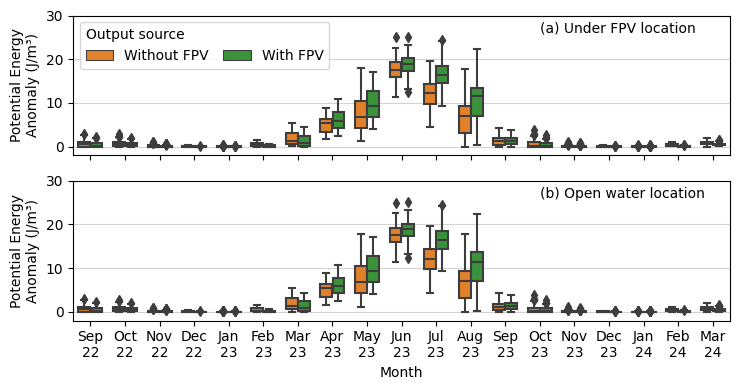

In [47]:
# Plot graph with delta between scenarios and control run
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7.5,4], sharex = True, sharey = True)

pal = sns.color_palette("tab10",5)

# Under FPV location
sns.boxplot(x = "Month", y = "PEA", data = PEA_boxplot_df_underFPV,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax[0], hue = 'Simulation')

# ax[0].set_ylim(-2,21)
ax[0].tick_params(axis = 'y', which = 'major', labelsize = 10)
ax[0].yaxis.set_label_text(u'Potential Energy\nAnomaly (J/m³)', fontsize = 10)

ax[0].legend(title = "Output source", loc="upper left", ncol = 2, fontsize = 10, 
          frameon = True, columnspacing = 1)._legend_box.align = "left"
ax[0].set_axisbelow(True)
ax[0].grid(color='lightgray', axis = 'y')
ax[0].set(xlabel=None)

ax[0].text(13, 26, '(a) Under FPV location', color = 'k', fontsize = 10)

# Open water location
sns.boxplot(x = "Month", y = "PEA", data = PEA_boxplot_df_openwater,
            width = 0.7, boxprops = {'zorder': 1}, palette = pal[1:3], ax = ax[1], hue = 'Simulation')

# ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
#                  ['Sep\n22', 'Oct\n22', 'Nov\n22', 'Dec\n22', 'Jan\n23', 'Feb\n23', 'Mar\n23',
#                   'Apr\n23', 'May\n23', 'Jun\n23', 'Jul\n23', 'Aug\n23', 'Sep\n23', 'Oct\n23',
#                   'Nov\n23', 'Dec\n23', 'Jan\n24', 'Feb\n24', 'Mar\n24'],
#                  fontsize = 10)

ax[1].set_ylim(-2,30)
ax[1].tick_params(axis = 'y', which = 'major', labelsize = 10)
ax[1].yaxis.set_label_text(u'Potential Energy\nAnomaly (J/m³)', fontsize = 10)
ax[1].legend_.remove()
ax[1].set_axisbelow(True)
ax[1].grid(color='lightgray', axis = 'y')

ax[1].text(13, 26, '(b) Open water location', color = 'k', fontsize = 10)

ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
                 ['Sep\n22', 'Oct\n22', 'Nov\n22', 'Dec\n22', 'Jan\n23', 'Feb\n23', 'Mar\n23',
                  'Apr\n23', 'May\n23', 'Jun\n23', 'Jul\n23', 'Aug\n23', 'Sep\n23', 'Oct\n23',
                  'Nov\n23', 'Dec\n23', 'Jan\n24', 'Feb\n24', 'Mar\n24'],
                 fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(figs_path + 'PEA_monthly_boxplots_FPV_eqgrid.jpeg', dpi = 600, bbox_inches='tight')

plt.show();